# Experiment 1: NGRC Weight Analysis on the Lorenz System

## Objectives

- Generate Lorenz system data and train an NGRC model with $k = 1$.
- Extract and examine the learned NGRC weights.
- Identify the most influential linear and nonlinear features.
- Compare the learned terms with the Euler-discretized Lorenz equations.
- Investigate whether NGRC recovers the known dynamical structure of the Lorenz system.
- Visualize and interpret the dominant interactions governing the system dynamics.

In [253]:
# Source: LorenzConstLinQuadraticNVARtimedelay-RK23.py

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path


In [254]:
# Output directories

OUTPUT_DIR = Path("../outputs")
DATA = Path("../data")

PROCESS = DATA / "processed"

IMAGE_DIR = OUTPUT_DIR / "images" / "lrz63"
LOG_DIR = OUTPUT_DIR / "logs"

LOG_FILE = LOG_DIR / "analysis_report.txt"

IMAGE_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)

In [255]:
df = pd.read_csv(
    PROCESS / "enso_hw_te_interp14.csv"
)

df["date"] = pd.to_datetime(
    df["date"]
)

enso = (
    df[["west_h", "east_t"]]
    .rolling(
        window=90,
        center=True,
        min_periods=1
    )
    .mean()
)

enso = enso.dropna().reset_index(drop=True)

enso = (
    enso
    - enso.mean()
) / enso.std()

print(enso.shape)

print(enso.isna().sum())

(14588, 2)
west_h    0
east_t    0
dtype: int64


## Simulation and NVAR Parameters

### ENSO Data

In [256]:
enso.values

array([[ 1.08543793, -0.79938949],
       [ 1.08952328, -0.80758058],
       [ 1.09485237, -0.80654495],
       ...,
       [ 0.2661484 ,  1.75892644],
       [ 0.24139748,  1.75956944],
       [ 0.21985838,  1.75987534]], shape=(14588, 2))

In [257]:
def build_ngrc_features(enso, d, k):

    data = enso.values

    maxtime_pts = data.shape[0] - 1
    dlin = d * k

    x = np.zeros((dlin, maxtime_pts))

    for delay in range(k):
        for j in range(delay, maxtime_pts):

            x[d*delay:d*(delay+1), j] = data[j-delay]

    return x

In [258]:
def train_ngrc(
    x,
    d,
    k,
    warmup_pts,
    warmtrain_pts,
    traintime_pts,
    ridge_param,
    total_var,
):

    dlin = d * k

    dnonlin = dlin * (dlin + 1) // 2

    dtot = 1 + dlin + dnonlin

    out_train = np.ones((dtot, traintime_pts))

    out_train[1:dlin + 1, :] = (
        x[:, warmup_pts - 1:warmtrain_pts - 1]
    )

    cnt = 0

    for i in range(dlin):

        for j in range(i, dlin):

            out_train[dlin + 1 + cnt, :] = (
                x[i, warmup_pts - 1:warmtrain_pts - 1]
                * x[j, warmup_pts - 1:warmtrain_pts - 1]
            )

            cnt += 1

    Y = (
        x[0:d, warmup_pts:warmtrain_pts]
        - x[0:d, warmup_pts - 1:warmtrain_pts - 1]
    )

    W_out = (
        Y
        @ out_train.T
        @ np.linalg.pinv(
            out_train @ out_train.T
            + ridge_param * np.eye(dtot)
        )
    )

    x_predict = (
        x[0:d, warmup_pts - 1:warmtrain_pts - 1]
        + W_out @ out_train
    )

    train_true = x[
        0:d,
        warmup_pts:warmtrain_pts,
    ]

    train_nrmse = np.sqrt(
        np.mean(
            (
                train_true
                - x_predict
            ) ** 2
        ) / total_var
    )

    return (
        W_out,
        train_nrmse,
        x_predict,
        train_true,
    )

In [259]:
def predict_ngrc(
    x,
    W_out,
    d,
    k,
    warmtrain_pts,
    testtime_pts,
    lyaptime_pts,
    total_var,
):

    dlin = d * k
    dnonlin = dlin * (dlin + 1) // 2
    dtot = 1 + dlin + dnonlin

    out_test = np.zeros(dtot)

    x_test = np.zeros((dlin, testtime_pts))

    x_test[:, 0] = x[:, warmtrain_pts - 1]

    for j in range(testtime_pts - 1):

        out_test[1:dlin + 1] = x_test[:, j]

        cnt = 0

        for row in range(dlin):

            for col in range(row, dlin):

                out_test[dlin + 1 + cnt] = (
                    x_test[row, j]
                    * x_test[col, j]
                )

                cnt += 1

        if k > 1:

            x_test[d:dlin, j + 1] = (
                x_test[0:(dlin - d), j]
            )

        x_test[0:d, j + 1] = (
            x_test[0:d, j]
            + W_out @ out_test
        )

    true_segment = x[
        0:d,
        warmtrain_pts - 1:warmtrain_pts + lyaptime_pts - 1,
    ]

    pred_segment = x_test[
        0:d,
        0:lyaptime_pts,
    ]

    test_nrmse = np.sqrt(
        np.mean(
            (true_segment - pred_segment) ** 2
        ) / total_var
    )

    return x_test, test_nrmse

In [260]:
def predict_ngrc_old(
    x,
    W_out,
    d,
    k,
    warmtrain_pts,
    testtime_pts,
    lyaptime_pts,
    total_var,
):

    dlin = d * k
    dnonlin = dlin * (dlin + 1) // 2
    dtot = 1 + dlin + dnonlin

    out_test = np.zeros(dtot)

    x_test = np.zeros((dlin, testtime_pts))
    x_test[:, 0] = x[:, warmtrain_pts - 1]

    for j in range(testtime_pts - 1):

        out_test[1:dlin + 1] = x_test[:, j]

        cnt = 0

        for row in range(dlin):
            for col in range(row, dlin):

                out_test[dlin + 1 + cnt] = (
                    x_test[row, j]
                    * x_test[col, j]
                )

                cnt += 1

        x_test[d:dlin, j + 1] = x_test[0:(dlin - d), j]

        x_test[0:d, j + 1] = (
            x_test[0:d, j]
            + W_out @ out_test
        )

    true_segment = x[
        0:d,
        warmtrain_pts - 1:warmtrain_pts + lyaptime_pts - 1,
    ]

    pred_segment = x_test[
        0:d,
        0:lyaptime_pts,
    ]

    test_nrmse = np.sqrt(
        np.mean(
            (true_segment - pred_segment) ** 2
        ) / total_var
    )

    return x_test, test_nrmse

In [261]:
def run_experiment(enso, ridge_param=2.5e-6, k=1):

    d = enso.shape[1]

    n = len(enso)

    train_size = int(0.5 * n)

    warmup_pts = k

    traintime_pts = train_size - warmup_pts

    warmtrain_pts = train_size

    testtime_pts = n - train_size

    lyaptime_pts = min(100, testtime_pts)

    total_var = np.var(enso.values)

    x = build_ngrc_features(
        enso,
        d,
        k
    )

    W_out, train_nrmse, train_pred, train_true = train_ngrc(
        x,
        d,
        k,
        warmup_pts,
        warmtrain_pts,
        traintime_pts,
        ridge_param,
        total_var
    )

    x_test, test_nrmse = predict_ngrc(
        x,
        W_out,
        d,
        k,
        warmtrain_pts,
        testtime_pts,
        lyaptime_pts,
        total_var
    )

    return {

        "k": k,

        "ridge": ridge_param,

        "train_nrmse": train_nrmse,

        "test_nrmse": test_nrmse,

        "W_out": W_out,

        "train_pred": train_pred,

        "train_true": train_true,

        "x_test": x_test,

        "true_test": x[
            0:d,
            warmtrain_pts-1:warmtrain_pts+testtime_pts-1,
        ],

    }

In [262]:
def build_labels(d=2, k=1):

    variables = [r"$h_W$", r"$T_E$"]

    linear_labels = []

    for delay in range(k):

        for var in variables:

            if delay == 0:

                linear_labels.append(f"{var}(t)")

            else:

                linear_labels.append(f"{var}(t-{delay})")

    labels = ["1"] + linear_labels

    for i in range(len(linear_labels)):

        for j in range(i, len(linear_labels)):

            labels.append(
                f"{linear_labels[i]} × {linear_labels[j]}"
            )

    return labels

In [263]:
d = 2

k = 1

ridge_param = 2.5e-6

labels = build_labels(
    d=d,
    k=k
)

results = run_experiment(
    enso=enso,
    ridge_param=ridge_param,
    k=k,
)

print(f"Train NRMSE : {results['train_nrmse']:.4f}")

print(f"Test NRMSE : {results['test_nrmse']:.4f}")

print(results["W_out"].shape)

print("Completed run")

Train NRMSE : 0.0126
Test NRMSE : 0.2780
(2, 6)
Completed run


In [264]:
equations = [r"$h_W$", r"$T_E$"]

rows = []

for eq, equation in enumerate(equations):

    row = {
        "equation": equation,
        "train_nrmse": results["train_nrmse"],
        "test_nrmse": results["test_nrmse"],
    }

    W = results["W_out"]

    for i, label in enumerate(labels):

        row[label] = W[eq, i]

    rows.append(row)

weights_df = pd.DataFrame(rows)

weights_df.head()

,equation,train_nrmse,test_nrmse,1,$h_W$(t),$T_E$(t),$h_W$(t) × $h_W$(t),$h_W$(t) × $T_E$(t),$T_E$(t) × $T_E$(t)
0,$h_W$,0.012559,0.278008,-0.001983,-0.001330,-0.004830,0.000517,0.001126,0.001346
1,$T_E$,0.012559,0.278008,0.000953,0.004546,0.000922,0.000270,-0.001464,-0.000764


In [265]:
np.max(np.abs(results["W_out"]))

np.float64(0.004829847743717113)

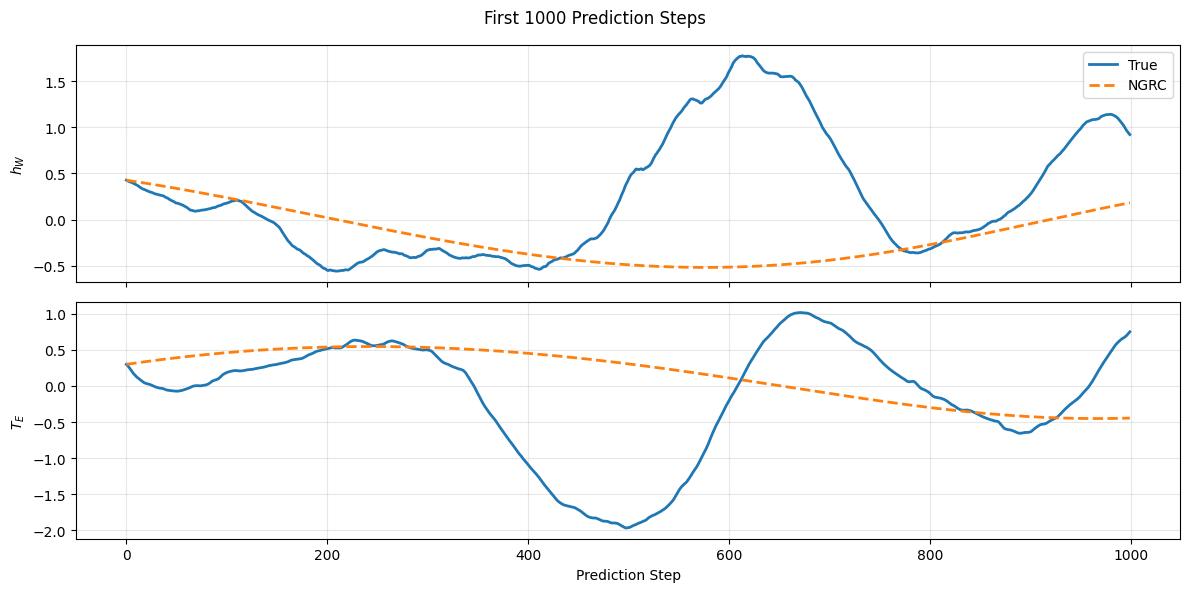

In [266]:
r = results

true = r["true_test"]

pred_ngrc = r["x_test"]

n = min(1000, pred_ngrc.shape[1])

names = [r"$h_W$", r"$T_E$"]

fig, axs = plt.subplots(
    2,
    1,
    figsize=(12, 6),
    sharex=True,
)

for i in range(2):

    axs[i].plot(
        true[i, :n],
        linewidth=2,
        label="True",
    )

    axs[i].plot(
        pred_ngrc[i, :n],
        "--",
        linewidth=2,
        label="NGRC",
    )

    axs[i].set_ylabel(
        names[i]
    )

    axs[i].grid(
        alpha=0.3
    )

axs[0].legend()

axs[-1].set_xlabel(
    "Prediction Step"
)

plt.suptitle(
    f"First {n} Prediction Steps"
)

plt.tight_layout()

plt.show()

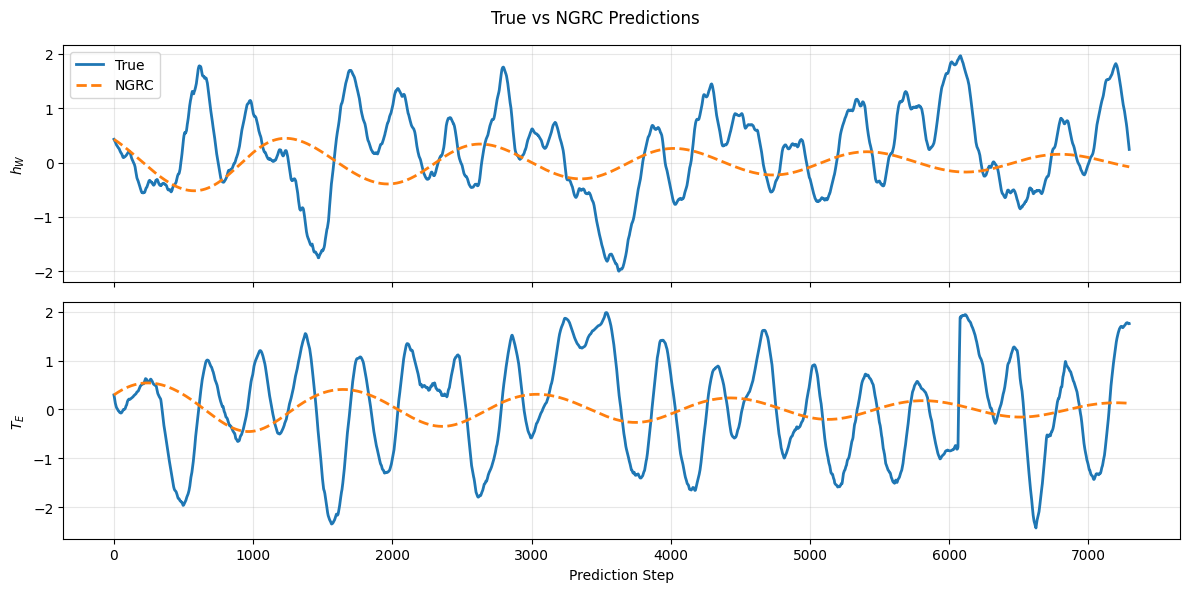

In [267]:
r = results

true = r["true_test"]

pred_ngrc = r["x_test"]

n = pred_ngrc.shape[1]

fig, axs = plt.subplots(
    2,
    1,
    figsize=(12, 6),
    sharex=True,
)

names = [r"$h_W$", r"$T_E$"]

for i in range(2):

    axs[i].plot(
        true[i, :n],
        linewidth=2,
        label="True",
    )

    axs[i].plot(
        pred_ngrc[i, :n],
        "--",
        linewidth=2,
        label="NGRC",
    )

    axs[i].set_ylabel(
        names[i]
    )

    axs[i].grid(
        alpha=0.3
    )

axs[0].legend()

axs[-1].set_xlabel(
    "Prediction Step"
)

plt.suptitle(
    "True vs NGRC Predictions"
)

plt.tight_layout()

plt.savefig(
    IMAGE_DIR / "true_vs_ngrc.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

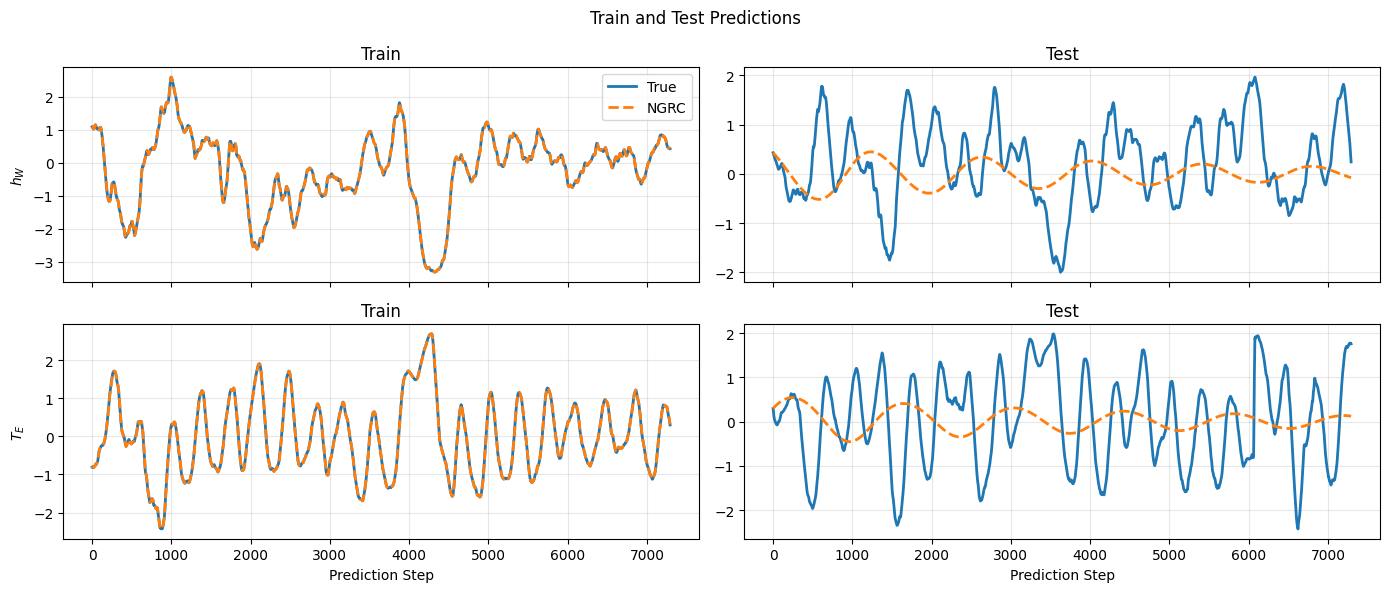

In [268]:
r = results

train_true = r["train_true"]

train_pred = r["train_pred"]

test_true = r["true_test"]

test_pred = r["x_test"]

names = [r"$h_W$", r"$T_E$"]

fig, axs = plt.subplots(
    2,
    2,
    figsize=(14,6),
    sharex="col",
)

for i in range(2):

    axs[i,0].plot(
        train_true[i],
        linewidth=2,
        label="True",
    )

    axs[i,0].plot(
        train_pred[i],
        "--",
        linewidth=2,
        label="NGRC",
    )

    axs[i,0].set_title(
        "Train"
    )

    axs[i,0].set_ylabel(
        names[i]
    )

    axs[i,0].grid(
        alpha=0.3
    )

    axs[i,1].plot(
        test_true[i],
        linewidth=2,
        label="True",
    )

    axs[i,1].plot(
        test_pred[i],
        "--",
        linewidth=2,
        label="NGRC",
    )

    axs[i,1].set_title(
        "Test"
    )

    axs[i,1].grid(
        alpha=0.3
    )

axs[0,0].legend()

axs[1,0].set_xlabel(
    "Prediction Step"
)

axs[1,1].set_xlabel(
    "Prediction Step"
)

plt.suptitle(
    "Train and Test Predictions"
)

plt.tight_layout()

plt.savefig(
    IMAGE_DIR / "train_test_predictions.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

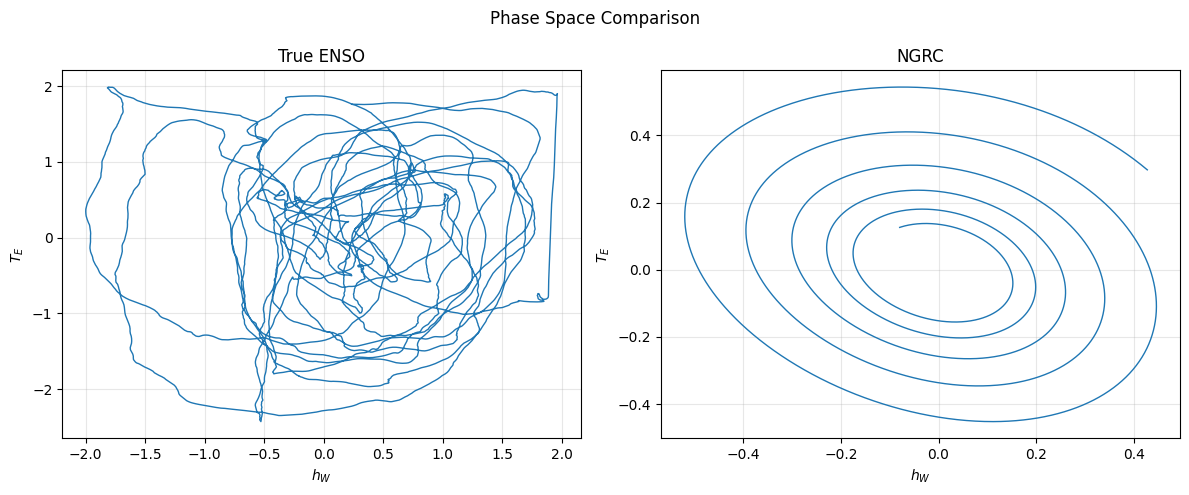

In [269]:
r = results

true = r["true_test"]

pred_ngrc = r["x_test"]

n = pred_ngrc.shape[1]

fig, axs = plt.subplots(
    1,
    2,
    figsize=(12,5),
)

# True

axs[0].plot(
    true[0, :n],
    true[1, :n],
    linewidth=1,
)

axs[0].set_title("True ENSO")

axs[0].set_xlabel(r"$h_W$")

axs[0].set_ylabel(r"$T_E$")

axs[0].grid(alpha=0.3)

# NGRC

axs[1].plot(
    pred_ngrc[0, :n],
    pred_ngrc[1, :n],
    linewidth=1,
)

axs[1].set_title("NGRC")

axs[1].set_xlabel(r"$h_W$")

axs[1].set_ylabel(r"$T_E$")

axs[1].grid(alpha=0.3)

plt.suptitle(
    "Phase Space Comparison"
)

plt.tight_layout()

plt.savefig(
    IMAGE_DIR / "phase_space_comparison.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [270]:
d = 2

k = 1

labels = build_labels(d=d, k=k)

ridge_values = [
    0,
    1e-8,
    1e-7,
    1e-6,
    1e-5,
    1e-4,
    1e-3,
    1e-2,
    1e-1,
    1,
    10,
    100,
]

results_ridge = []

for ridge in ridge_values:

    results_ridge.append(

        run_experiment(
            enso=enso,
            ridge_param=ridge,
            k=k,
        )

    )

    print(f"Completed ridge={ridge}")

summary_ridge = pd.DataFrame([

    {
        "ridge": r["ridge"],
        "train_nrmse": r["train_nrmse"],
        "test_nrmse": r["test_nrmse"],
    }

    for r in results_ridge

])

summary_ridge

Completed ridge=0
Completed ridge=1e-08
Completed ridge=1e-07
Completed ridge=1e-06
Completed ridge=1e-05
Completed ridge=0.0001
Completed ridge=0.001
Completed ridge=0.01
Completed ridge=0.1
Completed ridge=1
Completed ridge=10
Completed ridge=100


,ridge,train_nrmse,test_nrmse
0,0.000000e+00,0.012559,0.278008
1,1.000000e-08,0.012559,0.278008
2,1.000000e-07,0.012559,0.278008
3,1.000000e-06,0.012559,0.278008
4,1.000000e-05,0.012559,0.278008
5,1.000000e-04,0.012559,0.278008
6,1.000000e-03,0.012559,0.278008
7,1.000000e-02,0.012559,0.278008
8,1.000000e-01,0.012559,0.278007
9,1.000000e+00,0.012559,0.278003


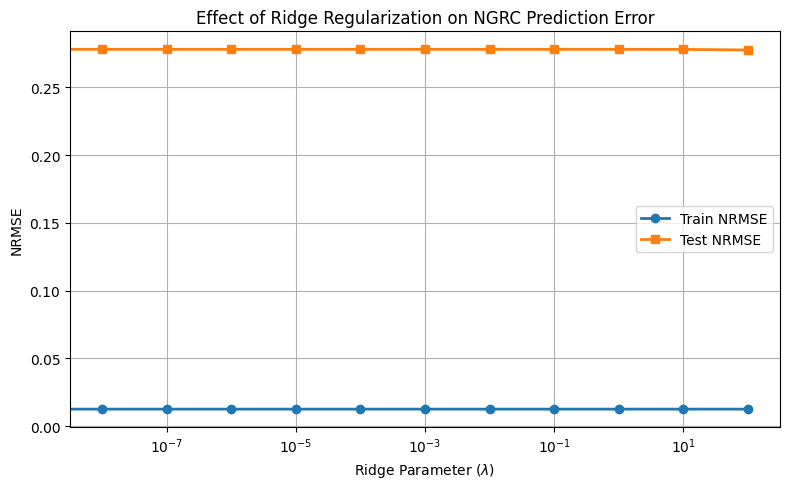

In [271]:
plt.figure(figsize=(8, 5))

plt.semilogx(
    summary_ridge["ridge"],
    summary_ridge["train_nrmse"],
    marker="o",
    linewidth=2,
    label="Train NRMSE",
)

plt.semilogx(
    summary_ridge["ridge"],
    summary_ridge["test_nrmse"],
    marker="s",
    linewidth=2,
    label="Test NRMSE",
)

plt.xlabel(r"Ridge Parameter ($\lambda$)")

plt.ylabel("NRMSE")

plt.title(
    r"Effect of Ridge Regularization on NGRC Prediction Error"
)

plt.grid(True, which="both")

plt.legend()

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/nrmse_vs_ridge.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()